# レジームスイッチングとARIMAを用いた市場動態のモデリング

このノートブックでは、S&P 500 (SPX) と米国10年国債利回り (DGS10) のデータに対し、**隠れマルコフモデル的なアプローチ（GMMによるレジーム分類＋推移確率行列）**と**レジームごとのARIMAX（外生変数付き自己回帰）モデル**を組み合わせた一連の分析パイプラインの理論と実装を解説します。

## 全体のパイプライン概要
1. **特徴量エンジニアリング**: SPXとDGS10の移動平均、標準偏差、および両者の相関係数を計算し、市場の「状態」を捉えやすくする。
2. **GMMによるクラスタリング**: 上記の特徴量をもとに、市場を4つの状態（レジーム）に分類する。
3. **推移確率行列の計算**: 状態間の遷移確率（マルコフ性）を経験的に計算する。
4. **状態ごとのARIMAモデリング**: 4つの状態それぞれにおいて、以下の2つのモデルを推定する。
   - SPXを予測するARIMA(2,1,1)モデル（DGS10の1日前の値を外生変数として使用）
   - DGS10を予測するARIMA(2,1,1)モデル（SPXの1日前の値を外生変数として使用）
5. **予測値の出力**: 各状態のモデルを使って算出したフィッティング値（予測値）を実際のデータと比較する。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from statsmodels.tsa.arima.model import ARIMA
import warnings
import sys
import os

# DCC-GARCH リポジトリのパスを追加
repo_path = os.path.join(os.getcwd(), 'DCC_GARCH_repo')
if repo_path not in sys.path:
    sys.path.append(repo_path)


try:
    from DCC_GARCH.DCC.DCC import DCC
    from DCC_GARCH.DCC.DCC_loss import dcc_loss_gen, R_gen
except ImportError as e:
    print("DCC-GARCH repository import failed:", e)

warnings.filterwarnings('ignore')


## 1. データの読み込みと特徴量エンジニアリング

### 理論
金融市場は常に同じ法則で動いているわけではなく、「ボラティリティが高い時期」「金利と株価が逆相関になる時期」など、マクロ的な環境（レジーム）が変化します。
この環境変化を捉えるため、単純な価格だけでなく、「20日（約1ヶ月）の移動平均、標準偏差、および相関」という**ローリング特徴量**を作成します。
これにより、瞬間的なノイズではなく、一定期間のトレンドやボラティリティの強さを元に状態を分類できるようになります。


In [2]:
df = pd.read_csv('/home/u00118/train_sp500_us10y.csv')
if 'Unnamed: 0' in df.columns:
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df.set_index('Date', inplace=True)
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ローリング特徴量の作成 (20日 = 約1ヶ月)
window = 20
df['sp500_roll_mean'] = df['sp500'].rolling(window=window).mean()
df['DGS10_roll_mean'] = df['DGS10'].rolling(window=window).mean()
df['sp500_roll_std'] = df['sp500'].rolling(window=window).std()
df['DGS10_roll_std'] = df['DGS10'].rolling(window=window).std()
df['corr'] = df['sp500'].rolling(window=window).corr(df['DGS10'])

# もう一方の変数の過去1日分のデータ（外生変数用）
df['DGS10_lag1'] = df['DGS10'].shift(1)
df['sp500_lag1'] = df['sp500'].shift(1)

# 欠損値の削除
df_features = df.dropna().copy()
print(f"有効なデータ件数: {len(df_features)}件")

features = df_features[['sp500_roll_mean', 'DGS10_roll_mean', 'sp500_roll_std', 'DGS10_roll_std', 'corr']]


有効なデータ件数: 14715件


## 2. GMMを用いた4つの状態（レジーム）へのクラスタリング

### 理論と計算手法（数式）
GMM（Gaussian Mixture Model: 混合ガウスモデル）は、データが複数の正規分布の集まり（混合分布）から生成されていると仮定し、それぞれのデータがどの分布から生成されたか（どの状態に属するか）を確率的に推定する手法です。ここでは $K=4$ として市場を4つの異なるレジームに分類しています。

**1. モデルの確率密度関数**
特徴量ベクトル $x$ が与えられたときの全体の確率分布 $P(x)$ は、各レジームの正規分布の線形結合として表されます。
$$
P(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$
* $K$: レジームの数 ($K=4$)
* $\pi_k$: レジーム $k$ が出現する事前確率（混合係数, $\sum \pi_k = 1$）
* $\mathcal{N}(x \mid \mu_k, \Sigma_k)$: 平均 $\mu_k$、共分散行列 $\Sigma_k$ を持つ多変量正規分布

**2. EMアルゴリズムによるパラメータ推定**
未知のパラメータ $\theta = \{\pi_k, \mu_k, \Sigma_k\}$ は、尤度が最大になるように **EMアルゴリズム** によって反復計算で推定されます。

* **Eステップ (Expectation)**: 現在のパラメータを用いて、各データ点 $x_i$ がレジーム $k$ に属する事後確率（負担率） $\gamma(z_{ik})$ を計算します。
$$
\gamma(z_{ik}) = \frac{\pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}
$$
* **Mステップ (Maximization)**: 計算された事後確率を用いて、各レジームのパラメータを更新します。
$$
\mu_k = \frac{1}{N_k} \sum_{i=1}^N \gamma(z_{ik}) x_i
$$
$$
\Sigma_k = \frac{1}{N_k} \sum_{i=1}^N \gamma(z_{ik}) (x_i - \mu_k)(x_i - \mu_k)^T
$$
$$
\pi_k = \frac{N_k}{N} \quad \left( ここで \ N_k = \sum_{i=1}^N \gamma(z_{ik}) \right)
$$

**3. レジームの判定**
EMアルゴリズムが収束した後、各時点 $t$ における市場のレジーム $S_t$ は、最も事後確率が高い分布として割り当てられます（ハードクラスタリング）。
$$
S_t = \arg\max_k \gamma(z_{tk})
$$
これにより、「平穏な上昇相場」「荒れ相場」などが自動的にグループ化されます。


各レジームのデータ件数:
Regime
0    1490
1    5146
2     449
3    7630
Name: count, dtype: int64


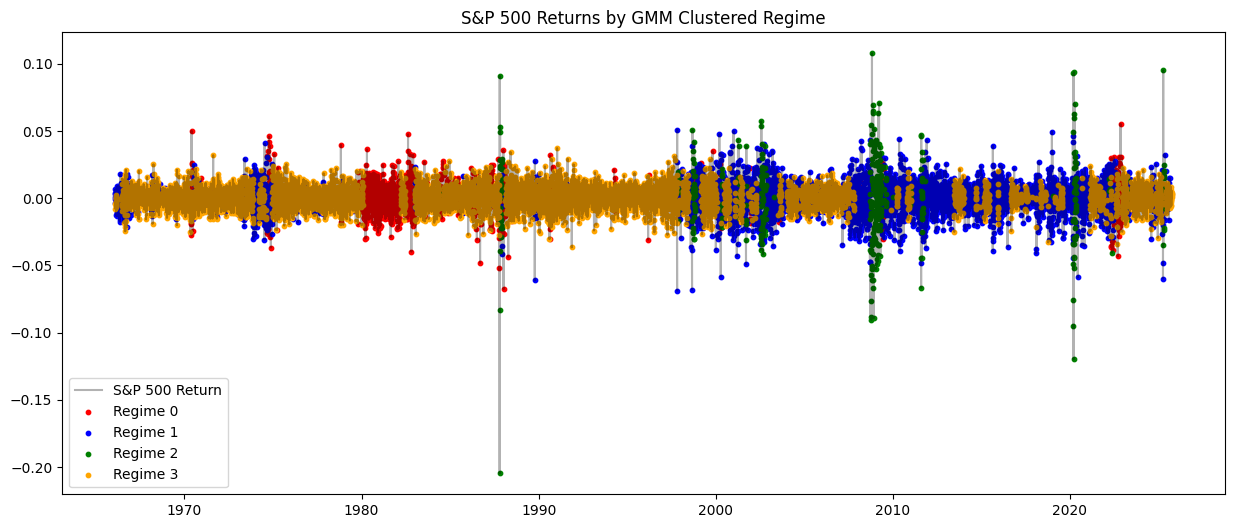

In [3]:
gmm = GaussianMixture(n_components=4, random_state=42, n_init=10)
df_features['Regime'] = gmm.fit_predict(features)

print("各レジームのデータ件数:")
print(df_features['Regime'].value_counts().sort_index())

# 状態の可視化
plt.figure(figsize=(15, 6))
plt.plot(df_features.index, df_features['sp500'], color='black', alpha=0.3, label='S&P 500 Return')
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    mask = df_features['Regime'] == i
    plt.scatter(df_features.index[mask], df_features['sp500'][mask], color=colors[i], label=f'Regime {i}', s=10)
plt.title('S&P 500 Returns by GMM Clustered Regime')
plt.legend()
plt.show()


## 3. 状態遷移確率行列の計算

### 理論
市場のレジームは、ランダムに切り替わるわけではありません。「荒れ相場」の次の日は「荒れ相場」になりやすいといった**持続性（マルコフ性）**があります。
推移確率行列（Transition Matrix）は、「現在の状態が $i$ のとき、次の日に状態が $j$ になる確率 $P(S_{t+1}=j | S_t=i)$」を行列にしたものです。
対角成分（[0,0]や[1,1]など）が大きいほど、その状態が持続しやすいことを意味します。


In [4]:
transition_matrix = np.zeros((4, 4))
regimes = df_features['Regime'].values
for t in range(1, len(regimes)):
    from_state = regimes[t-1]
    to_state = regimes[t]
    transition_matrix[from_state, to_state] += 1

# 行ごとに正規化して確率に変換
transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)

print("【推移確率行列 (Transition Matrix)】")
for i in range(4):
    print(f"状態 {i} からの遷移確率: [0]:{transition_matrix[i,0]:.3f}, [1]:{transition_matrix[i,1]:.3f}, [2]:{transition_matrix[i,2]:.3f}, [3]:{transition_matrix[i,3]:.3f}")


【推移確率行列 (Transition Matrix)】
状態 0 からの遷移確率: [0]:0.936, [1]:0.013, [2]:0.004, [3]:0.048
状態 1 からの遷移確率: [0]:0.004, [1]:0.948, [2]:0.006, [3]:0.042
状態 2 からの遷移確率: [0]:0.020, [1]:0.062, [2]:0.915, [3]:0.002
状態 3 からの遷移確率: [0]:0.009, [1]:0.029, [2]:0.000, [3]:0.963


## 4. 状態ごとのARIMAモデリング

### 理論
時系列データが全体を通して同じ法則に従う（定常的である）と仮定すると、構造変化を見落としてしまいます。そこで、レジームごとに別々のARIMAモデルを推定します。
* **ARIMA (2,1,1)**: 階差(d=1)を取りつつ、過去2日分の自己回帰(AR=2)と過去1日分の移動平均(MA=1)を考慮するモデル。
* **exog (外生変数)**: SPXのモデルにはDGS10の過去1日分のデータを、DGS10のモデルにはSPXの過去1日分のデータを組み込む（ARIMAX）。これにより、「前日の金利変動が今日の株価に与える影響」なども考慮できます。


In [19]:
# モデルの保存用辞書
models_sp500 = {}
models_dgs = {}
models_dcc = {}

for i in range(4):
    print(f"\n--- レジーム {i} のモデルフィッティング ---")
    mask = df_features['Regime'] == i
    
    # 1. SPX の ARIMA モデル (exog=DGS10_lag1)
    y_sp500 = df_features['sp500'].copy()
    y_sp500[~mask] = np.nan # 該当レジーム以外はNaNにしてKalman Filterで欠損値扱いにする
    exog_dgs = df_features['DGS10_lag1']
    
    try:
        model_sp500 = ARIMA(endog=y_sp500, exog=exog_dgs, order=(2, 1, 1))
        res_sp500 = model_sp500.fit()
        models_sp500[i] = res_sp500
        print(f"【SPX 推定パラメータ】\n{res_sp500.params}")
    except Exception as e:
        print(e)

    # 2. DGS10 の ARIMA モデル (exog=sp500_lag1)
    y_dgs = df_features['DGS10'].copy()
    y_dgs[~mask] = np.nan
    exog_sp500 = df_features['sp500_lag1']
    
    try:
        model_dgs = ARIMA(endog=y_dgs, exog=exog_sp500, order=(2, 1, 1))
        res_dgs = model_dgs.fit()
        models_dgs[i] = res_dgs
        print(f"\n【DGS10 推定パラメータ】\n{res_dgs.params}")
    except Exception as e:
        print(e)
        
    # 3. DCC-GARCH モデルのフィッティング
    if i in models_sp500 and i in models_dgs:
        print(f"\n【DCC-GARCH モデルフィッティング】")
        # ARIMAの残差を取得 (mask部分のみ)
        resid_sp = models_sp500[i].resid[mask]
        resid_dgs = models_dgs[i].resid[mask]
        
        sigma2_sp = models_sp500[i].params.get('sigma2', 1e-6)
        sigma2_dgs = models_dgs[i].params.get('sigma2', 1e-6)
        
        # 標準化残差 (e_t = residual / sigma)
        e_sp = resid_sp / np.sqrt(sigma2_sp)
        e_dgs = resid_dgs / np.sqrt(sigma2_dgs)
        
        # リポジトリの仕様 [e_T, ..., e_0] に合わせるため、逆順にして 2xT の行列を作成
        tr = np.array([e_sp[::-1], e_dgs[::-1]])
        
        try:
            dcc_model = DCC(max_itr=5)
            dcc_model.set_loss(dcc_loss_gen())
            dcc_model.fit(tr)
            ab = dcc_model.get_ab()
            models_dcc[i] = (ab, tr)
            print(f"最適化された DCC パラメータ (a, b) = {ab}")
        except Exception as e:
            print("DCC フィッティング中にエラー:", e)




--- レジーム 0 のモデルフィッティング ---
【SPX 推定パラメータ】
DGS10_lag1   -0.002672
ar.L1         0.076456
ar.L2         0.006679
ma.L1        -0.994945
sigma2        0.000139
dtype: float64

【DGS10 推定パラメータ】
sp500_lag1    0.230999
ar.L1         0.067867
ar.L2         0.024224
ma.L1        -0.999922
sigma2        0.017643
dtype: float64

【DCC-GARCH モデルフィッティング】
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2831.6955758990516
            Iterations: 15
            Function evaluations: 49
            Gradient evaluations: 15
Iteration: 1. Training loss: 2.832E+03.
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2831.6955758983922
            Iterations: 1
            Function evaluations: 9
            Gradient evaluations: 1
Iteration: 2. Training loss: 2.832E+03.
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2831.6955758975596
            Iterations: 1
            Function eval

### 予測値とシミュレーションデータの生成
DCC-GARCH モデルによって動的に変化する相関行列（$R_t$）を用いて、毎日のボラティリティと相関を反映したシミュレーションを生成します。


In [25]:
df_features['sp500_pred'] = np.nan
df_features['DGS10_pred'] = np.nan
df_features['sp500_simulated'] = np.nan
df_features['DGS10_simulated'] = np.nan

for i in range(4):
    mask = df_features['Regime'] == i
    
    if i in models_sp500 and i in models_dgs and i in models_dcc:
        res_sp500 = models_sp500[i]
        res_dgs = models_dgs[i]
        ab, tr = models_dcc[i]
        
        # 予測値の計算
        pred_mean_sp = res_sp500.predict()[mask]
        pred_mean_dgs = res_dgs.predict()[mask]
        df_features.loc[mask, 'sp500_pred'] = pred_mean_sp
        df_features.loc[mask, 'DGS10_pred'] = pred_mean_dgs
        
        # ARIMA の固定分散
        sigma2_sp = res_sp500.params.get('sigma2', 0)
        sigma2_dgs = res_dgs.params.get('sigma2', 0)
        std_sp = np.sqrt(sigma2_sp)
        std_dgs = np.sqrt(sigma2_dgs)
        
        # DCC による日別の動的相関行列 (R_t) のリストを取得
        R_list = R_gen(tr, ab)
        # trは逆順[e_T, ..., e_0]だったため、R_listも[R_T, ..., R_0]になっているので元の時系列順に戻す
        R_list_chrono = R_list[::-1]
        
        shocks_sp = np.zeros(mask.sum())
        shocks_dgs = np.zeros(mask.sum())
        
        # 時点ごとに多変量正規分布からショックを生成
        for t in range(mask.sum()):
            R_t = R_list_chrono[t]
            rho_t = R_t[0, 1]
            
            # 共分散行列の構築: Cov(X, Y) = rho * std(X) * std(Y)
            cov_t = rho_t * std_sp * std_dgs
            cov_matrix_t = [[sigma2_sp, cov_t],
                            [cov_t, sigma2_dgs]]
            
            # 各時点の動的相関行列に基づいてショックを1つ生成
            shock_t = np.random.multivariate_normal([0, 0], cov_matrix_t)
            shocks_sp[t] = shock_t[0]
            shocks_dgs[t] = shock_t[1]
        
        # シミュレーション値の計算（予測値 + 動的相関を持つノイズ）
        df_features.loc[mask, 'sp500_simulated'] = pred_mean_sp + shocks_sp
        df_features.loc[mask, 'DGS10_simulated'] = pred_mean_dgs + shocks_dgs

print("DCC-GARCHの動的相関を反映したシミュレーションデータを生成しました！")


DCC-GARCHの動的相関を反映したシミュレーションデータを生成しました！


## 5. 出力と評価

### 理論: DCC-GARCHを用いた動的相関のシミュレーション

上記で推定したモデルを用いて算出した「予測値（sp500_pred）」は、正確には「条件付き期待値（平均）」です。
金融市場のリターンはノイズが大きいため、単純な期待値だけでは市場特有の「荒々しさ（ボラティリティ）」を表現できません。

さらに、株と金利の「相関」は時間が経つにつれて日々変化します。そこで、本モデルでは **DCC-GARCH（動的条件付き相関モデル）** を導入してシミュレーション値を算出しています。

**数式での表現:**

1. 予測値（条件付き期待値）:
$$
\hat{y}_t = E[y_t \mid \mathcal{F}_{t-1}]
$$

2. 動的相関行列 ($R_t$) の更新プロセス (DCC):
$$
Q_t = (1 - a - b)\bar{Q} + a (z_{t-1} z_{t-1}^T) + b Q_{t-1}
$$
$$
R_t = \text{diag}(Q_t)^{-1/2} Q_t \text{diag}(Q_t)^{-1/2}
$$
（※ $z_t$ はARIMAの標準化残差、$a, b$ はDCCモデルによって最適化されたパラメータです）

3. シミュレーション値（予測値 + 動的相関を持つランダムショック）:
$$
\begin{pmatrix} y_{sp, t} \\ y_{dgs, t} \end{pmatrix}_{sim} = \begin{pmatrix} \hat{y}_{sp, t} \\ \hat{y}_{dgs, t} \end{pmatrix} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}\left(0, D R_t D\right)
$$
（※ $D$ は各モデルの標準偏差を対角成分に持つ行列です）




【直近10日間の実際の値と予測値・シミュレーション値】


,Regime,sp500,sp500_pred,sp500_simulated,DGS10,DGS10_pred,DGS10_simulated
Date,,,,,,,
2025-09-19,3,0.004885,0.000584,0.003190,0.03,0.002180,-0.022434
2025-09-22,3,0.004410,0.000478,-0.005936,0.01,0.000826,-0.057849
2025-09-23,3,-0.005502,0.000473,0.001565,-0.03,-0.000306,-0.063087
2025-09-24,3,-0.002847,-0.000349,0.006336,0.04,0.000279,0.072626
2025-09-25,3,-0.005009,0.000022,-0.011211,0.02,0.004079,-0.003935
2025-09-26,3,0.005902,-0.000200,0.001639,0.02,0.003266,0.013610
2025-09-29,3,0.002636,0.000865,0.000888,-0.05,-0.000282,0.054790
2025-09-30,3,0.004091,0.000403,0.005690,0.01,-0.003721,0.066751
2025-10-01,3,0.003400,0.000493,0.019521,-0.04,0.000025,0.025387


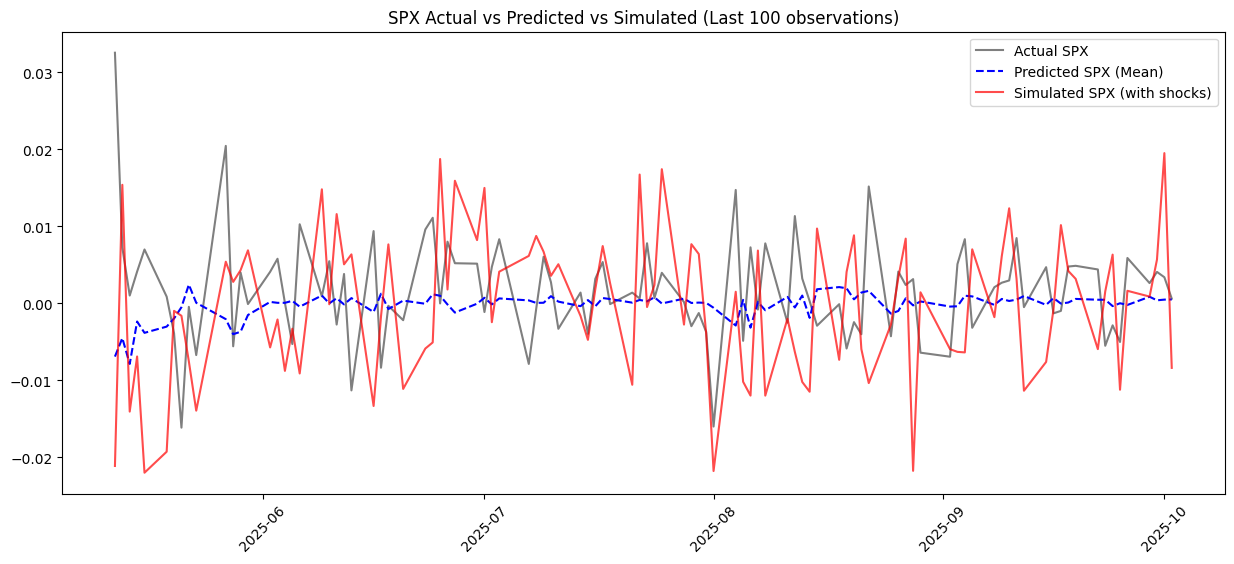

In [26]:
# 最後の出力をする際に、小数点以下6桁に丸める
round_cols = ['sp500_pred', 'sp500_simulated', 'DGS10_pred', 'DGS10_simulated']
df_features[round_cols] = df_features[round_cols].round(6)

output_df = df_features[['Regime', 'sp500', 'sp500_pred', 'sp500_simulated', 'DGS10', 'DGS10_pred', 'DGS10_simulated']]
print("【直近10日間の実際の値と予測値・シミュレーション値】")
display(output_df.tail(10))

# 実際の値と予測値・シミュレーション値のプロット
plt.figure(figsize=(15, 6))
plt.plot(output_df.index[-100:], output_df['sp500'][-100:], label='Actual SPX', color='black', alpha=0.5)
plt.plot(output_df.index[-100:], output_df['sp500_pred'][-100:], label='Predicted SPX (Mean)', color='blue', linestyle='--')
plt.plot(output_df.index[-100:], output_df['sp500_simulated'][-100:], label='Simulated SPX (with shocks)', color='red', alpha=0.7)
plt.title('SPX Actual vs Predicted vs Simulated (Last 100 observations)')
plt.xticks(rotation=45)
plt.legend()
plt.show()


## 6. 全期間での累積リターンの比較

初期値を $1$ として、実際のSPXリターンとモデルの予測リターン（`sp500_pred`）を累積（複利計算）して比較します。
これにより、モデルの予測通りに運用した場合の長期的なパフォーマンスと、実際の市場のパフォーマンスの乖離を視覚的に評価できます。


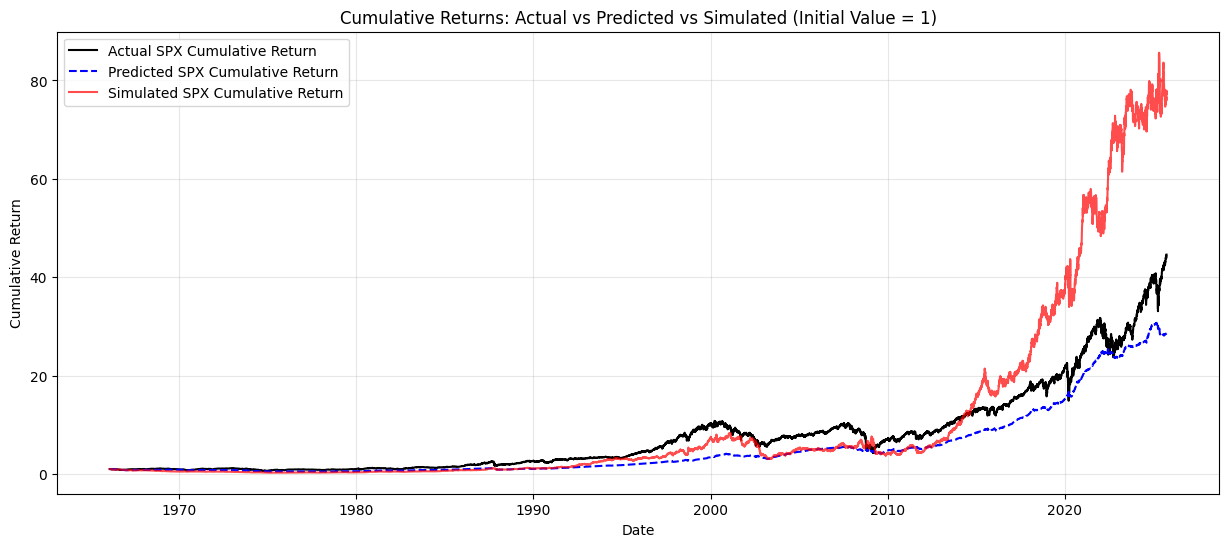

In [27]:
# 欠損値（NaN）を0で埋めてから累積積（cumprod）を計算
df_features['cum_sp500'] = (1 + df_features['sp500'].fillna(0)).cumprod()
df_features['cum_sp500_pred'] = (1 + df_features['sp500_pred'].fillna(0)).cumprod()
df_features['cum_sp500_sim'] = (1 + df_features['sp500_simulated'].fillna(0)).cumprod()

plt.figure(figsize=(15, 6))
plt.plot(df_features.index, df_features['cum_sp500'], label='Actual SPX Cumulative Return', color='black')
plt.plot(df_features.index, df_features['cum_sp500_pred'], label='Predicted SPX Cumulative Return', color='blue', linestyle='--')
plt.plot(df_features.index, df_features['cum_sp500_sim'], label='Simulated SPX Cumulative Return', color='red', alpha=0.7)
plt.title('Cumulative Returns: Actual vs Predicted vs Simulated (Initial Value = 1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. 実データとモデル生成データ（予測・シミュレーション）の相関比較

モデルが、S&P 500 と米国10年国債利回り (DGS10) の「2資産間の関係性（相関）」をどれだけ上手く再現できているかを検証します。
* **実データの相関係数**: 実際のSPXとDGS10のリターンの相関
* **予測データの相関係数**: モデルの期待値（予測値）どうしの相関
* **シミュレーションデータの相関係数**: 乱数ノイズを加えたシミュレーション値どうしの相関


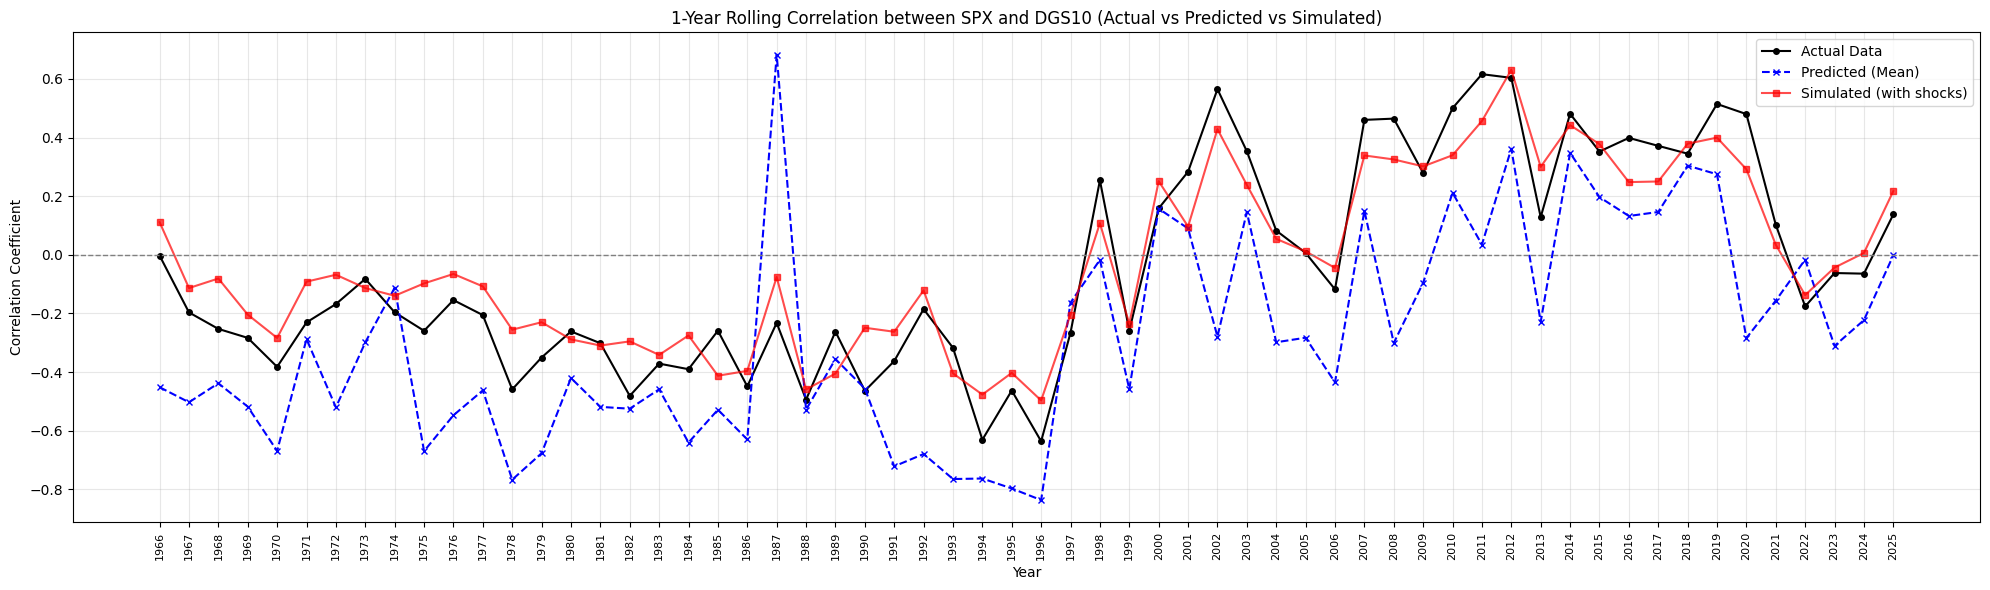


【相関係数のボラティリティ（標準偏差）の比較】
1. 実データの相関のボラティリティ            : 0.3500
2. 予測データ(期待値)の相関のボラティリティ  : 0.3533
3. シミュレーションの相関のボラティリティ    : 0.2877


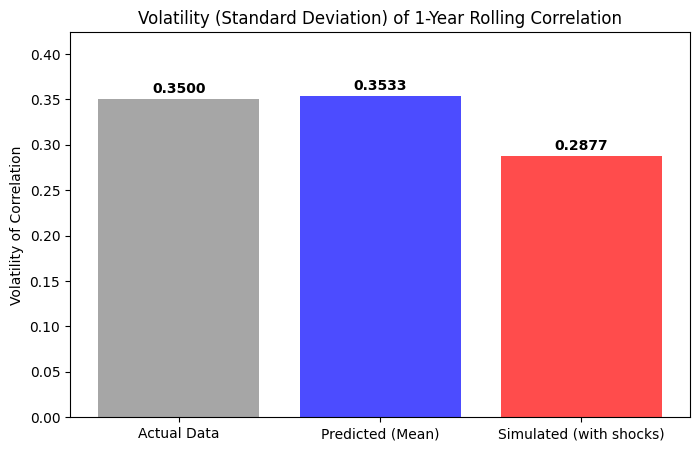

In [28]:
# 1年ごとのビンを作成
df_features['1Y_Label'] = df_features.index.year.astype(str)

# 1年ごとに相関を計算
corr_act = df_features.groupby('1Y_Label').apply(lambda g: g['sp500'].corr(g['DGS10']))
corr_pred = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_pred'].corr(g['DGS10_pred']))
corr_sim = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_simulated'].corr(g['DGS10_simulated']))

corr_1y = pd.DataFrame({'Actual': corr_act, 'Predicted': corr_pred, 'Simulated': corr_sim})



# 折れ線グラフで視覚化
plt.figure(figsize=(20, 6))
plt.plot(corr_1y.index, corr_1y['Actual'], marker='o', label='Actual Data', color='black', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Predicted'], marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Simulated'], marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5, markersize=4)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.title('1-Year Rolling Correlation between SPX and DGS10 (Actual vs Predicted vs Simulated)')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
# X軸のラベル（年）が多くなるので90度回転させて間隔を整える
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 相関係数のボラティリティ比較
vol_act = corr_1y['Actual'].std()
vol_pred = corr_1y['Predicted'].std()
vol_sim = corr_1y['Simulated'].std()

print("\n【相関係数のボラティリティ（標準偏差）の比較】")
print(f"1. 実データの相関のボラティリティ            : {vol_act:.4f}")
print(f"2. 予測データ(期待値)の相関のボラティリティ  : {vol_pred:.4f}")
print(f"3. シミュレーションの相関のボラティリティ    : {vol_sim:.4f}")

# ボラティリティを棒グラフで視覚化
plt.figure(figsize=(8, 5))
labels_vol = ['Actual Data', 'Predicted (Mean)', 'Simulated (with shocks)']
values_vol = [vol_act, vol_pred, vol_sim]
colors_vol = ['gray', 'blue', 'red']

plt.bar(labels_vol, values_vol, color=colors_vol, alpha=0.7)
plt.title('Volatility (Standard Deviation) of 1-Year Rolling Correlation')
plt.ylabel('Volatility of Correlation')
for i, v in enumerate(values_vol):
    # NaNが含まれる場合のフェイルセーフ
    if pd.notna(v):
        plt.text(i, v + (max([val for val in values_vol if pd.notna(val)] + [0])*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.ylim(0, max([val for val in values_vol if pd.notna(val)] + [0.1]) * 1.2)
plt.show()
